# 2.  Representations of Numbers and Other Objects

This section is much more "computing", with only a bit of physics.  But we need to have some understanding of how a computer works in order to realize what the issues are that affect physics calculations, and in particular which objects are precisely determined and which are approximated.

The simplest variable is a logical variable, which can either be "True" or "False".  In python, these are represented by a single bit, which can either be zero or one.




In [1]:
print('Values for True and False are', hex(True),hex(False))

Values for True and False are 0x1 0x0


Modern computers typically have 64 "bits"--- that is, each memory address refers to 64 transistor switches, each one can be "on" or "off". 

By convention, bits are arranged into "bytes", which contain 8 bits and can encode 256 different items. We often break a byte down into two hexadecimal digits, since a hexadecimal digit can represent 16 objects, labelled from 0,1,2,3,4,5,6,7,8,9,A,B,C,D,E,F.  

One can make 2\*\*64 different arrangements with 64 bits.  This is the same as the number of heads/tails patterns one can make with 64 flips of a coin. 

In [2]:
print(2**64)
max=2**64
print(f'{max:,}')

18446744073709551616
18,446,744,073,709,551,616


The simplest and most widely used encoding is just base 2--- if all switches are off we call the number 0, if bit one is on- 1 etc.  

In [1]:
for j in range(0,100):
    print(j, bin(j), hex(j))

0 0b0 0x0
1 0b1 0x1
2 0b10 0x2
3 0b11 0x3
4 0b100 0x4
5 0b101 0x5
6 0b110 0x6
7 0b111 0x7
8 0b1000 0x8
9 0b1001 0x9
10 0b1010 0xa
11 0b1011 0xb
12 0b1100 0xc
13 0b1101 0xd
14 0b1110 0xe
15 0b1111 0xf
16 0b10000 0x10
17 0b10001 0x11
18 0b10010 0x12
19 0b10011 0x13
20 0b10100 0x14
21 0b10101 0x15
22 0b10110 0x16
23 0b10111 0x17
24 0b11000 0x18
25 0b11001 0x19
26 0b11010 0x1a
27 0b11011 0x1b
28 0b11100 0x1c
29 0b11101 0x1d
30 0b11110 0x1e
31 0b11111 0x1f
32 0b100000 0x20
33 0b100001 0x21
34 0b100010 0x22
35 0b100011 0x23
36 0b100100 0x24
37 0b100101 0x25
38 0b100110 0x26
39 0b100111 0x27
40 0b101000 0x28
41 0b101001 0x29
42 0b101010 0x2a
43 0b101011 0x2b
44 0b101100 0x2c
45 0b101101 0x2d
46 0b101110 0x2e
47 0b101111 0x2f
48 0b110000 0x30
49 0b110001 0x31
50 0b110010 0x32
51 0b110011 0x33
52 0b110100 0x34
53 0b110101 0x35
54 0b110110 0x36
55 0b110111 0x37
56 0b111000 0x38
57 0b111001 0x39
58 0b111010 0x3a
59 0b111011 0x3b
60 0b111100 0x3c
61 0b111101 0x3d
62 0b111110 0x3e
63 0b111111 0x3f


In [2]:
0b1100011

99

In [3]:
print(bin(2**64-1))  #this lets you see the 64 switches turned on
print(oct(2**64-1))  #octal (base 8)
print(hex(2**64-1))  #hexidecimal (base 16)

0b1111111111111111111111111111111111111111111111111111111111111111
0o1777777777777777777777
0xffffffffffffffff


This works fine for positive integers, which are often called unsigned integers in computer languages.  For signed integers, we typically use "two's complement" notation:

In [7]:
import numpy as np
for j in range(0, 100):
    k=2**32-j  #use 32 bits as an example
    print(-j,"=","{:b}".format(k))  #this prints the binary representation of 0 to -100

0 = 100000000000000000000000000000000
-1 = 11111111111111111111111111111111
-2 = 11111111111111111111111111111110
-3 = 11111111111111111111111111111101
-4 = 11111111111111111111111111111100
-5 = 11111111111111111111111111111011
-6 = 11111111111111111111111111111010
-7 = 11111111111111111111111111111001
-8 = 11111111111111111111111111111000
-9 = 11111111111111111111111111110111
-10 = 11111111111111111111111111110110
-11 = 11111111111111111111111111110101
-12 = 11111111111111111111111111110100
-13 = 11111111111111111111111111110011
-14 = 11111111111111111111111111110010
-15 = 11111111111111111111111111110001
-16 = 11111111111111111111111111110000
-17 = 11111111111111111111111111101111
-18 = 11111111111111111111111111101110
-19 = 11111111111111111111111111101101
-20 = 11111111111111111111111111101100
-21 = 11111111111111111111111111101011
-22 = 11111111111111111111111111101010
-23 = 11111111111111111111111111101001
-24 = 11111111111111111111111111101000
-25 = 11111111111111111111111111100

In [11]:
import math
print('65!=',math.factorial(65))
text=str(math.factorial(200))
print(len(text), text)

65!= 8247650592082470666723170306785496252186258551345437492922123134388955774976000000000000000
375 788657867364790503552363213932185062295135977687173263294742533244359449963403342920304284011984623904177212138919638830257642790242637105061926624952829931113462857270763317237396988943922445621451664240254033291864131227428294853277524242407573903240321257405579568660226031904170324062351700858796178922222789623703897374720000000000000000000000000000000000000000000000000


If we have a 32 bit computer then the "overflow" bit is thrown out.  This means that the computer designer doesn't need to do anything special to handle negative integers.  They simply get treated like integers, and it is only the "outside" world that needs to know that they are signed integers instead of naturnal numbers.

Python doesn't use the (highly efficient) fixed length registers to handle integers.  It allows integers of arbitrary length, and a separate sign bit, and one can do arbitary sized integer arithmetic.  



# Other codes:  Gray code, ASCII, color maps, etc. 


There are other specialty codes.  The *Gray Code* is used for numerical applications where you only one bit to change at a time-- so for instance for shaft encoders.



In [8]:
n=5
for i in range(0, 2**n):
    gray=i^(i//2) #"^= bitwise exclusive or" and //="integer divide"
    print(i,"{0:0{1}b}".format(gray,n))


0 00000
1 00001
2 00011
3 00010
4 00110
5 00111
6 00101
7 00100
8 01100
9 01101
10 01111
11 01110
12 01010
13 01011
14 01001
15 01000
16 11000
17 11001
18 11011
19 11010
20 11110
21 11111
22 11101
23 11100
24 10100
25 10101
26 10111
27 10110
28 10010
29 10011
30 10001
31 10000


In [9]:
#demonstrate exclusive or
for i in range(0,31):
    j=i^3
    print(f'{i},{i:b},{j:b},{j}')

0,0,11,3
1,1,10,2
2,10,1,1
3,11,0,0
4,100,111,7
5,101,110,6
6,110,101,5
7,111,100,4
8,1000,1011,11
9,1001,1010,10
10,1010,1001,9
11,1011,1000,8
12,1100,1111,15
13,1101,1110,14
14,1110,1101,13
15,1111,1100,12
16,10000,10011,19
17,10001,10010,18
18,10010,10001,17
19,10011,10000,16
20,10100,10111,23
21,10101,10110,22
22,10110,10101,21
23,10111,10100,20
24,11000,11011,27
25,11001,11010,26
26,11010,11001,25
27,11011,11000,24
28,11100,11111,31
29,11101,11110,30
30,11110,11101,29


In [10]:
#demonstrate integer division
6//4 #integer division

1

   ## Ascii 
   Ascii codes are used to represent letters rather than numbers.  It allows for 128 characters, some of which are "control characters" (linefeed, or carriage return for instance).
   
 How does the computer do operations on Ascii characters?  What operations make sense?
 

In [11]:
[str(x)+':   '+chr(x) for x in range(128)]

['0:   \x00',
 '1:   \x01',
 '2:   \x02',
 '3:   \x03',
 '4:   \x04',
 '5:   \x05',
 '6:   \x06',
 '7:   \x07',
 '8:   \x08',
 '9:   \t',
 '10:   \n',
 '11:   \x0b',
 '12:   \x0c',
 '13:   \r',
 '14:   \x0e',
 '15:   \x0f',
 '16:   \x10',
 '17:   \x11',
 '18:   \x12',
 '19:   \x13',
 '20:   \x14',
 '21:   \x15',
 '22:   \x16',
 '23:   \x17',
 '24:   \x18',
 '25:   \x19',
 '26:   \x1a',
 '27:   \x1b',
 '28:   \x1c',
 '29:   \x1d',
 '30:   \x1e',
 '31:   \x1f',
 '32:    ',
 '33:   !',
 '34:   "',
 '35:   #',
 '36:   $',
 '37:   %',
 '38:   &',
 "39:   '",
 '40:   (',
 '41:   )',
 '42:   *',
 '43:   +',
 '44:   ,',
 '45:   -',
 '46:   .',
 '47:   /',
 '48:   0',
 '49:   1',
 '50:   2',
 '51:   3',
 '52:   4',
 '53:   5',
 '54:   6',
 '55:   7',
 '56:   8',
 '57:   9',
 '58:   :',
 '59:   ;',
 '60:   <',
 '61:   =',
 '62:   >',
 '63:   ?',
 '64:   @',
 '65:   A',
 '66:   B',
 '67:   C',
 '68:   D',
 '69:   E',
 '70:   F',
 '71:   G',
 '72:   H',
 '73:   I',
 '74:   J',
 '75:   K',
 '76:   

## Unicode
See https://docs.python.org/3/howto/unicode.html

## GIF
See https://en.wikipedia.org/wiki/GIF

There are a wide variety of other encodings for other types of information- movies, sound etc.  Basically, all of these end up having a "code book", like the GIF, with definitions of bytes, etc.  

# Floating Point Numbers

It is very often the case that integers aren't right for a calculation.  In particular, we typically encode real numbers as floating point- basically we break a block of memory down into an exponent and a mantissa.  This is so widespread that computer hardware understands things, and has special registers (floating point units) that are able to multiply, add, subtract, divide, take the square root of such numbers, and perhaps even do sin, cos, etc.



In [12]:
import sys
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

There is a cost to doing this-- numbers are not represented exactly, but only to a number of bits.  So we show the representations of a number of floating point numbers:

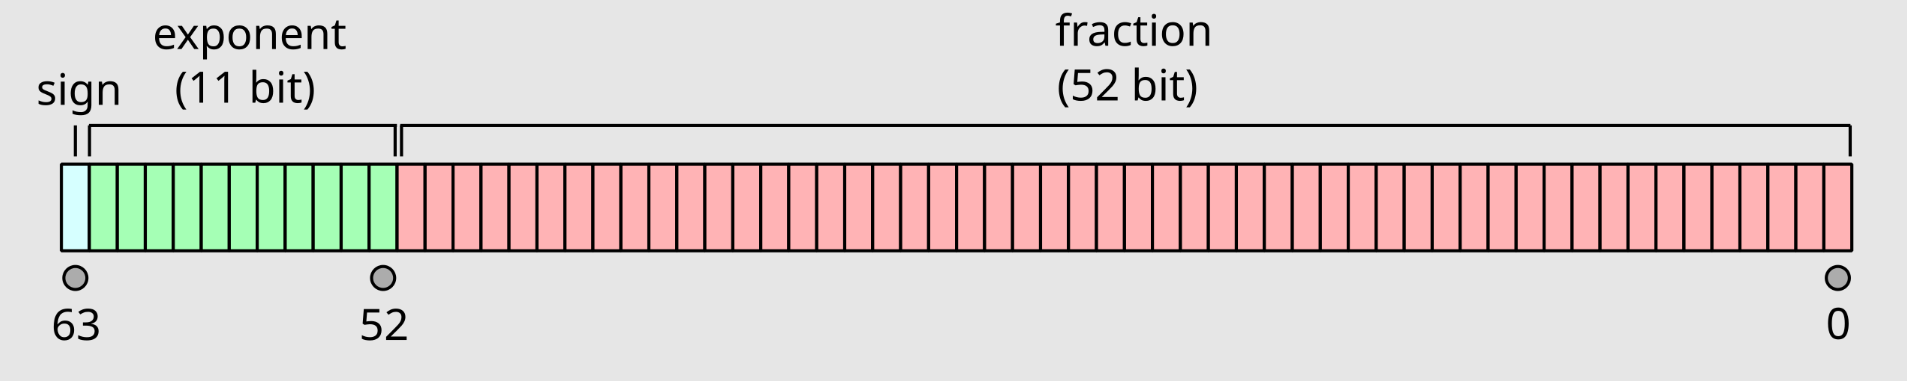

(By Codekaizen - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=3595583)

In [13]:
x=0.1
print(float.hex(x)) 
x=0.01
print(x,float.hex(x))
for x in [1.0,2.0,3.0,6.0,12.0,24.0,1e-5, 1e-4, 1e-3]:
    print(x,float.hex(x))

import numpy as np
count=0;
for x in np.linspace(1,10000,10000):
    y=1.0/x
    if x*y !=1.0:
        count=count+1
        if count<100:
            print(f'{x}*1/{x}',float.hex(x*y), 1-x*y)
print(f"There were {count} such numbers between 1 and 10000")

0x1.999999999999ap-4
0.01 0x1.47ae147ae147bp-7
1.0 0x1.0000000000000p+0
2.0 0x1.0000000000000p+1
3.0 0x1.8000000000000p+1
6.0 0x1.8000000000000p+2
12.0 0x1.8000000000000p+3
24.0 0x1.8000000000000p+4
1e-05 0x1.4f8b588e368f1p-17
0.0001 0x1.a36e2eb1c432dp-14
0.001 0x1.0624dd2f1a9fcp-10
49.0*1/49.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
98.0*1/98.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
103.0*1/103.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
107.0*1/107.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
161.0*1/161.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
187.0*1/187.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
196.0*1/196.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
197.0*1/197.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
206.0*1/206.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
214.0*1/214.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
237.0*1/237.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
239.0*1/239.0 0x1.fffffffffffffp-1 1.1102230246251565e-16
249.0*1/249.0 0x1.ffffff

# Computer Instructions

Computer instructions are also encoded as bits in memory.  They do things like move data from memory into a register, add/subtract/divide/bitwise and, or, xor  the contents of memory to a register, move data from a register to memory.  Instruction and memory addresses are simply strings of bits in memory.  

To illustrate, we write a simple "C" code, which we compile (translate to machine language), and then run through a debugger.  (See adjacent slides).

# Python Variables
Python variables are a lot like "gifs".  They contain a block of memory that describe a "Python Object", and contains the information about how to add, subtract, etc. that object.  

Numpy uses variables that are the same as on the computer, and enables the formation of arrays and operations on arrays that are essentially at the same speed as a computer working with its "native" representations.


In [30]:

print(float.hex(2000.0),hex(2000))

0x1.f400000000000p+10 0x7d0


0.09239202400203794

In [19]:
help(timeit)

Help on module timeit:

NAME
    timeit - Tool for measuring execution time of small code snippets.

MODULE REFERENCE
    https://docs.python.org/3.10/library/timeit.html
    
    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    This module avoids a number of common traps for measuring execution
    times.  See also Tim Peters' introduction to the Algorithms chapter in
    the Python Cookbook, published by O'Reilly.
    
    Library usage: see the Timer class.
    
    Command line usage:
        python timeit.py [-n N] [-r N] [-s S] [-p] [-h] [--] [statement]
    
    Options:
      -n/--number N: how many times to execute 'statement' (default: see below)
      -r/--repeat N: how many times to repeat the t

In [39]:
for x in np.logspace(1,30,50):
    y=x*10**3
    z=1./x*10**-3
    if y*z !=1:
       print(x,y,z,y*z)

print(1.002002002002002e-3,1.002002002002002*10**-3)
print(1.4444444444444444e-3,1.4444444444444444*10**-3)


39.069399370546165 39069.39937054616 2.5595479226995362e-05 0.9999999999999999
596.3623316594642 596362.3316594642 1.6768329368110084e-06 0.9999999999999999
2329.951810515372 2329951.810515372 4.2919342601287785e-07 1.0000000000000002
542867.543932386 542867543.9323859 1.8420699693267162e-09 0.9999999999999999
8286427.728546843 8286427728.546843 1.2067926406393287e-10 0.9999999999999999
32374575.428176403 32374575428.176403 3.088843596477484e-11 0.9999999999999999
126485521.68552957 126485521685.52957 7.906043210907701e-12 0.9999999999999999
1930697728.8832457 1930697728883.2456 5.179474679231223e-13 0.9999999999999999
29470517025.518097 29470517025518.098 3.3932217718953294e-14 0.9999999999999999
115139539932.6448 115139539932644.81 8.685113737513521e-15 1.0000000000000002
449843266896.9453 449843266896945.3 2.222996482526191e-15 0.9999999999999999
1757510624854.7893 1757510624854789.2 5.689866029018305e-16 0.9999999999999999
26826957952797.273 2.682695795279727e+16 3.7275937203149376